M1: [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

M2: [[1.  0.5]
 [0.  1. ]]

M1 × M2 (Combined):
[[ 0.70710678 -0.35355339]
 [ 0.70710678  1.06066017]]

After M2 (Shear): [[0.  1.  1.5 0.5 0. ]
 [0.  0.  1.  1.  0. ]]

After M1 then M2  [[ 0.          0.70710678  0.35355339 -0.35355339  0.        ]
 [ 0.          0.70710678  1.76776695  1.06066017  0.        ]]

Direct combined (M1 @ M2) [[ 0.          0.70710678  0.35355339 -0.35355339  0.        ]
 [ 0.          0.70710678  1.76776695  1.06066017  0.        ]]



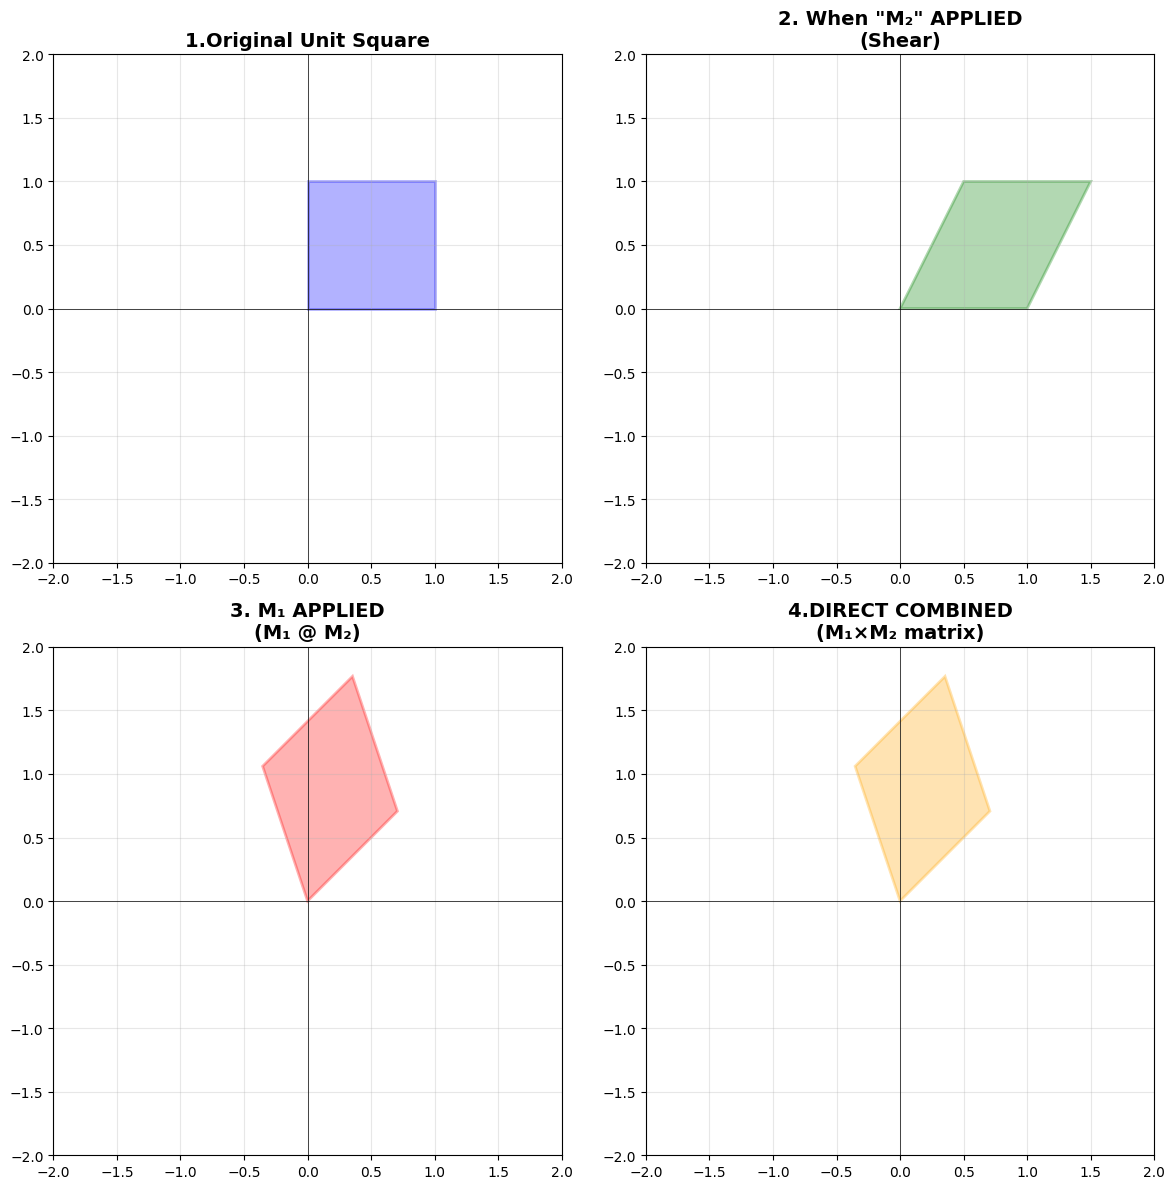

Are 3 and 4 the same?

Method 1 (Step by step):
  Top right corner: [0.35355339 1.76776695]

Method 2 (Direct combined):
  Top right corner: [0.35355339 1.76776695]
Yes, both methods give the same result.


In [21]:

# Understanding MATRIX MULTIPLICATION = TRANSFORMATION COMPOSITION

import numpy as np
import matplotlib.pyplot as plt

def rotation_matrix(angle_degrees):
    """Create rotation matrix"""
    theta = np.radians(angle_degrees)
    return  np.array([[np.cos(theta), -np.sin(theta)],
                     [np.sin(theta),  np.cos(theta)]])


def shear_matrix(shear_x=0, shear_y=0):
    """Shear matrix"""
    return np.array([[1, shear_x],
                     [shear_y, 1]])

# Transformation matrices
M1 = rotation_matrix(45)
M2 = shear_matrix(shear_x=0.5)
print("M1:", M1)
print()
print("M2:", M2)

M_combined = M1 @ M2
print("\nM1 × M2 (Combined):")
print(M_combined)
print()
square = np.array([[0, 1, 1, 0, 0],
                   [0, 0, 1, 1, 0]])


# proof of "(M1 @ M2) @ square  =  M1 @ (M2 @ square)"
square_M2 = M2 @ square
square_M1M2 = M1 @ square_M2

square_combined = M_combined @ square # Direct combined
print("After M2 (Shear):" ,square_M2)
print()
print("After M1 then M2 ", square_M1M2)
print()
print("Direct combined (M1 @ M2)",square_combined)
print()

# VISUALIZATION
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# 1. Original Square
ax = axes[0, 0]
ax.fill(square[0], square[1], alpha=0.3, color='blue',
        edgecolor='blue', linewidth=2)
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_title('1.Original Unit Square',
             fontsize=14, fontweight='bold')
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)

# 2. M2 applied
ax = axes[0, 1]
ax.fill(square_M2[0], square_M2[1], alpha=0.3, color='green',
        edgecolor='green', linewidth=2)
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_title('2. When "M₂" APPLIED\n(Shear)',
             fontsize=14, fontweight='bold')
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)

# 3. M1 applied
ax = axes[1, 0]
ax.fill(square_M1M2[0], square_M1M2[1], alpha=0.3, color='red',
        edgecolor='red', linewidth=2)
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_title('3. M₁ APPLIED\n(M₁ @ M₂)',
             fontsize=14, fontweight='bold')
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)

# 4. Direct combined matrix
ax = axes[1, 1]
ax.fill(square_combined[0], square_combined[1], alpha=0.3, color='orange',
        edgecolor='orange', linewidth=2)
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_title('4.DIRECT COMBINED\n(M₁×M₂ matrix)',
             fontsize=14, fontweight='bold')
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

print("Are 3 and 4 the same?")

print("\nMethod 1 (Step by step):")
print(f"  Top right corner: {square_M1M2[:, 2]}")

print("\nMethod 2 (Direct combined):")
print(f"  Top right corner: {square_combined[:, 2]}")

if np.allclose(square_M1M2, square_combined):
    print("Yes, both methods give the same result.")
else:
    print("No, Results are different.")


